In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
!pip install kagglehub -q
import kagglehub
import os
import shutil

print("Download...")
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

os.makedirs('./data', exist_ok=True)
shutil.copytree(os.path.join(dataset_path, "Train"), './data/Train', dirs_exist_ok=True)
print("Dane gotowe w folderze ./data/Train !")

Download...
Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dane gotowe w folderze ./data/Train !


In [3]:
data_dir = './data/Train'  # Update this path!
batch_size = 1024
epochs = 15
num_classes = 43

# Automatically use GPU if available on Windows
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

In [5]:
# Custom wrapper to apply different transforms to Train/Val splits
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

print("Loading dataset...")
# Load raw dataset without transforms first, then split
base_dataset = datasets.ImageFolder(root=data_dir)

train_size = int(0.8 * len(base_dataset))
val_size = len(base_dataset) - train_size
train_subset, val_subset = random_split(base_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(123))

Loading dataset...


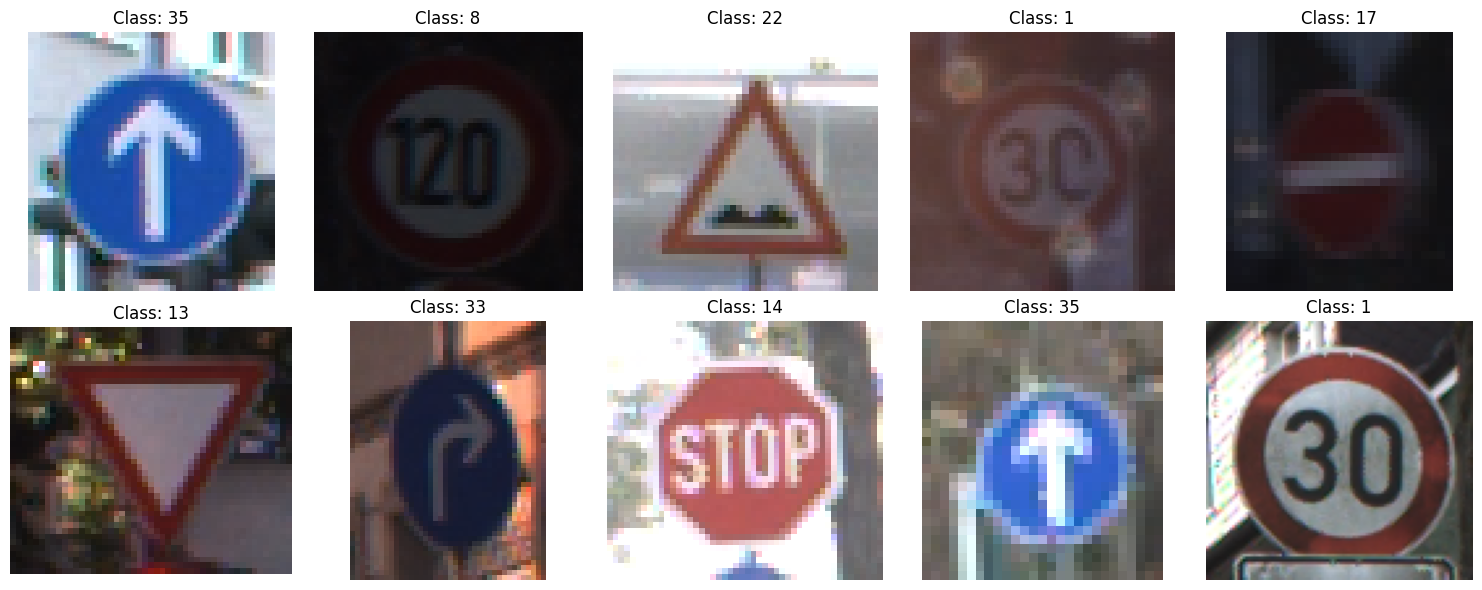

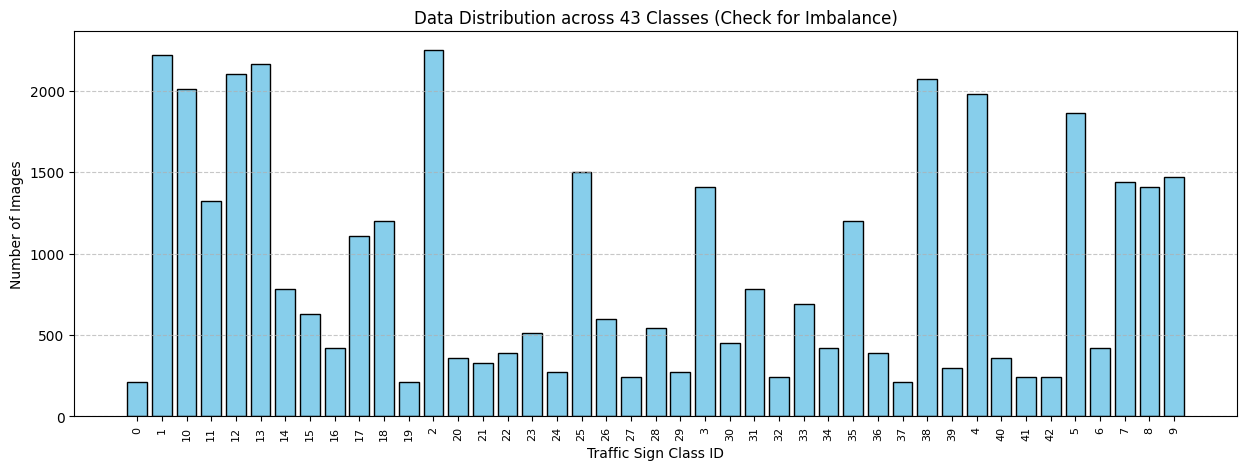

In [12]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# VISUALIZE 10 RANDOM IMAGES
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Select 10 random indices from the base dataset
random_indices = np.random.choice(len(base_dataset), 10, replace=False)

for i, idx in enumerate(random_indices):
    # Get image and label
    image, label = base_dataset[idx]

    axes[i].imshow(image)
    # base_dataset.classes contains folder names (which act as class labels)
    class_name = base_dataset.classes[label]
    axes[i].set_title(f"Class: {class_name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# VISUALIZE CLASS DISTRIBUTION
# Extract all labels from the dataset
all_labels = base_dataset.targets

# Count occurrences of each class
class_counts = Counter(all_labels)

# Sort by class index for better readability on x-axis
sorted_classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in sorted_classes]
class_names = [base_dataset.classes[c] for c in sorted_classes]

plt.figure(figsize=(15, 5))
plt.bar(class_names, counts, color='skyblue', edgecolor='black')
plt.xlabel('Traffic Sign Class ID')
plt.ylabel('Number of Images')
plt.title('Data Distribution across 43 Classes (Check for Imbalance)')
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [6]:
# Apply specific transforms
train_dataset = TransformedSubset(train_subset, transform=train_transforms)
val_dataset = TransformedSubset(val_subset, transform=val_transforms)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [7]:
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()

        self.features = nn.Sequential(
            # Conv Layer 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Conv Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Conv Layer 3
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            # Global Average Pooling (Handles dynamic sizes safely!)
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = TrafficSignCNN(num_classes=num_classes).to(device)

In [8]:
# nn.CrossEntropyLoss handles raw logits automatically (equivalent to from_logits=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
history = {'train_acc': [], 'val_acc': []}

print("Starting training...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Clear old gradients
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()                 # Backward pass (gradients)
        optimizer.step()                # Update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = correct_train / total_train
    history['train_acc'].append(train_accuracy)

    # --- VALIDATION PHASE ---
    model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad(): # Disable gradient calculation for speed/memory
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = correct_val / total_val
    history['val_acc'].append(val_accuracy)

    print(f"Train Acc: {train_accuracy*100:.2f}% | Val Acc: {val_accuracy*100:.2f}%")

Starting training...


Epoch 1/15: 100%|██████████| 31/31 [00:23<00:00,  1.30it/s]


Train Acc: 4.74% | Val Acc: 5.66%


Epoch 2/15: 100%|██████████| 31/31 [00:21<00:00,  1.46it/s]


Train Acc: 7.30% | Val Acc: 10.56%


...

Train Acc: 21.65% | Val Acc: 23.63%


Epoch 14/15: 100%|██████████| 31/31 [00:21<00:00,  1.47it/s]


Train Acc: 22.67% | Val Acc: 24.97%


Epoch 15/15: 100%|██████████| 31/31 [00:21<00:00,  1.45it/s]


Train Acc: 23.00% | Val Acc: 24.70%


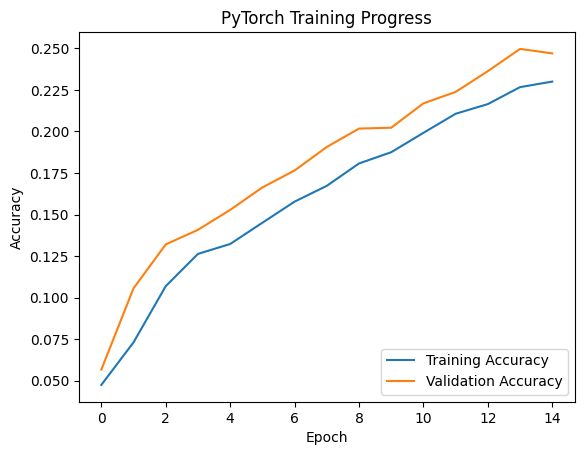

In [11]:
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('PyTorch Training Progress')
plt.show()

In [10]:
torch.save(model.state_dict(), 'traffic_sign_classifier.pth')
print("Model weights saved successfully as 'traffic_sign_classifier.pth'!")

Model weights saved successfully as 'traffic_sign_classifier.pth'!
